In [11]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

from data_analytics import get_transformed_data

from configs.base_config import *
from utils import get_dataloader
import matplotlib.pyplot as plt
from visualisation_utils import *
s=7

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

## Load without normalisation

In [24]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
config.normalisation = ''
print(config)

train_dataloader = get_dataloader(config.data_file,
                                  batch_size=10,
                                  fields=config.fields,
                                  normalisation=config.normalisation, shuffle=False)

idt = iter(train_dataloader)

extractor = train_dataloader.get_transform().uncall

TrainingConfig(data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar', gradient_accumulation_steps=1, learning_rate=0.0001, lr_warmup_steps=0, mixed_precision='no', seed=0, use_LDM=False, use_ema=False, base_output_dir='../../diffModel_experiences', lr_schedule='cosine_schedule', st_path=None, generation_frequency=50, pretrained_model_path=None, train_batch_size=8, train_steps_by_epoch=200, eval_batch_size=8, num_train_timesteps=1000, num_inference_steps=1000, num_epochs=5000, output_dir='wandb', fields={'toce': slice(0, -1, 2), 'soce': slice(0, -1, 2), 'ssh': slice(0, 1, None)}, normalisation='')
Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [30]:
batch = next(idt)

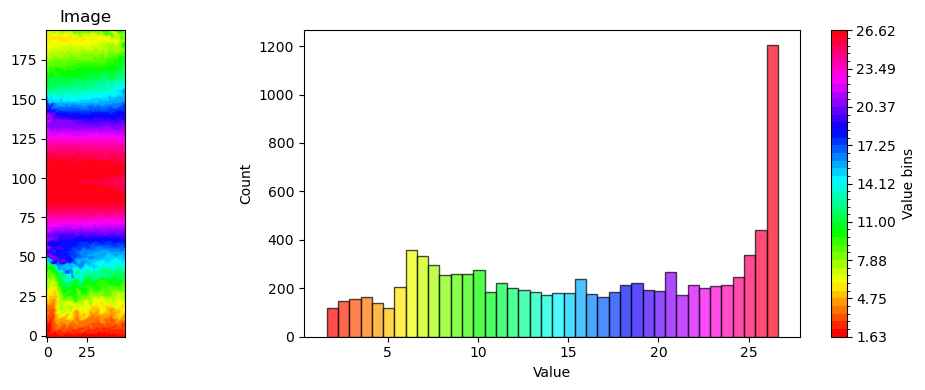

In [14]:
show_image_with_hist(batch[0,0, s:-s, s:-s], bins=40, cmap_name='hsv')

## Load with normalisation

In [28]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
print(config)

train_dataloader = get_dataloader(config.data_file,
                                  batch_size=10,
                                  fields=config.fields,
                                  normalisation=config.normalisation, shuffle=False)

idt = iter(train_dataloader)

extractor = train_dataloader.get_transform().uncall

TrainingConfig(data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar', gradient_accumulation_steps=1, learning_rate=0.0001, lr_warmup_steps=0, mixed_precision='no', seed=0, use_LDM=False, use_ema=False, base_output_dir='../../diffModel_experiences', lr_schedule='cosine_schedule', st_path=None, generation_frequency=50, pretrained_model_path=None, train_batch_size=8, train_steps_by_epoch=200, eval_batch_size=8, num_train_timesteps=1000, num_inference_steps=1000, num_epochs=5000, output_dir='wandb', fields={'toce': slice(0, -1, 2), 'soce': slice(0, -1, 2), 'ssh': slice(0, 1, None)}, normalisation='3-std')
Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [31]:
batch_normalised = next(idt)

In [32]:
batch_unnormalised = get_transformed_data(batch_normalised, function=extractor)

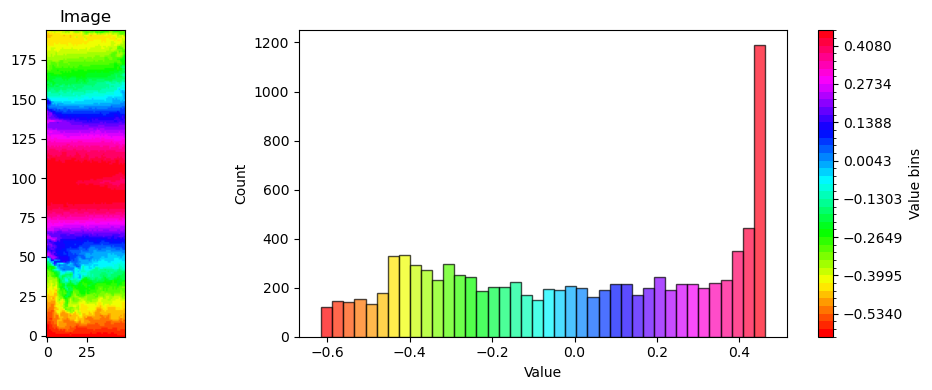

In [33]:
show_image_with_hist(batch_normalised[0,0, s:-s, s:-s], bins=40, cmap_name='hsv')

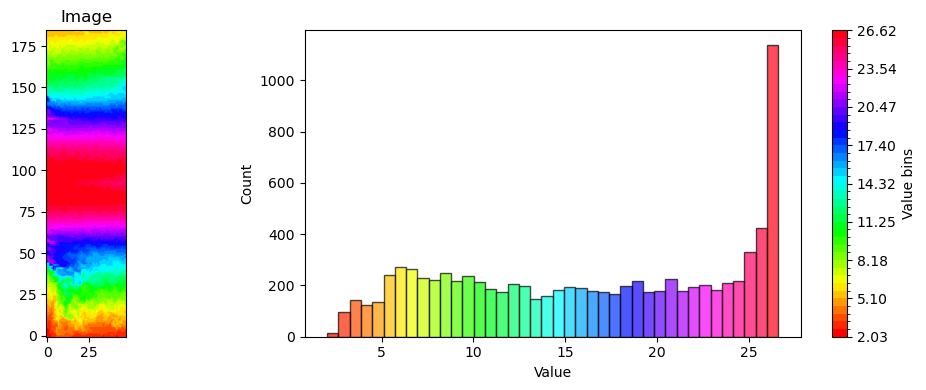

In [36]:
show_image_with_hist(batch_unnormalised['toce.npy'][0,0,s:-s, s:-s], bins=40, cmap_name='hsv')

Density

In [68]:
from metrics import get_density_at_surface_tensor
import torch

In [69]:
with torch.no_grad() : 
    density = get_density_at_surface_tensor(batch_unnormalised['toce.npy'], batch_unnormalised['soce.npy'], tmask=None)

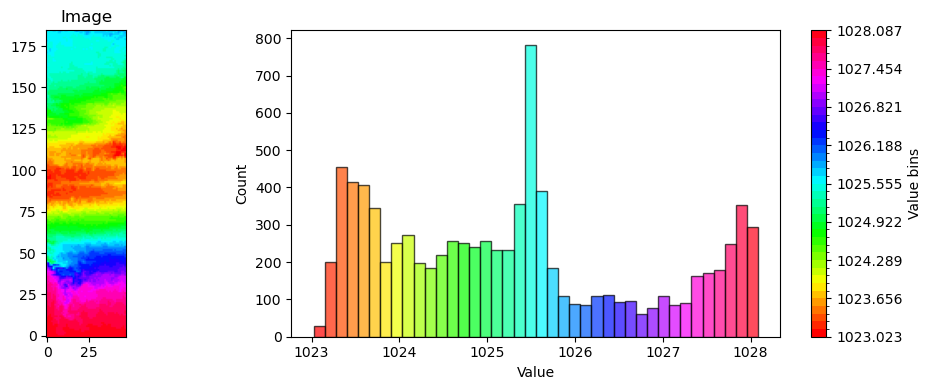

In [75]:
show_image_with_hist(density[0,0,s:-s, s:-s], bins=40, cmap_name='hsv')

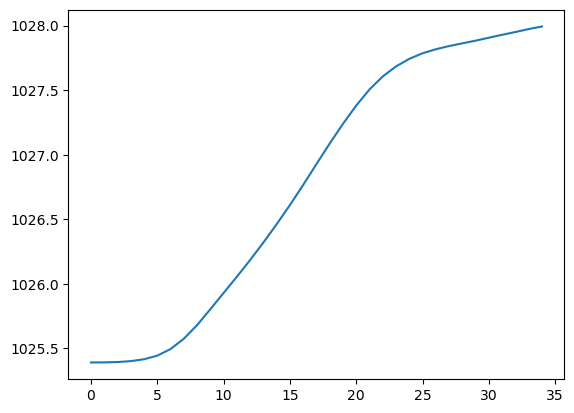

In [65]:
plt.plot(density[0].nanmean(axis=(-2,-1)).detach())